In [21]:
import qutip
import numpy as np
from qutip import *
import matplotlib.pyplot as plt
from typing import Union
from qutip import basis
import jax.numpy as jnp
import qutip_jax


In [22]:
#parameters
omega_c = 2 * np.pi * 50 #MHz
omega_t = 2 * np.pi * 25 #MHz
T_t = 1 * np.pi/omega_t
T_c = 1 * np.pi/omega_c
tmax = T_c * 2 + T_t * 3
V_dd = 2 * np.pi * 0 #MHz
tau_c = 548
tau_R = 505
gamma_c = 1/tau_c
gamma_R = 1/tau_R
Vdw = 2 * np.pi * 1 #MHz

In [23]:
tmax

0.08

In [24]:
#time list
tlist = np.linspace(0, tmax, 1000)

#control atom states
gc = basis(2,0) #|0>
rc = basis(2,1) #|1>

#dagger
gc_dag = gc.dag()  # <0|
rc_dag = rc.dag()  # <1|

#target atom states
gt = basis(3,0) 
et = basis(3,1)
rt = basis(3,2)

#dagger
gt_dag = gt.dag()
et_dag = et.dag()
rt_dag = rt.dag()

In [25]:
#control field
def Omega_c(t):
    if 0<=t<T_c:
        return omega_c/2
    elif T_c + 3 * T_t < t <= tmax:
        return - omega_c/2
    else:
        return 0

In [26]:
#target atoms
def Omega_p(t):
    if T_c<=t<T_c+T_t:
        return omega_t/2
    elif T_c + 2 * T_t <= t <= T_c + 3 * T_t:
        return omega_t/2
    else:
        return 0


def Omega_p2(t):
    if T_c + T_t <= t <= T_c + 2 * T_t:
        return - omega_t/2
    else:
        return 0

#def ht(t):
#    return Omega_p(t)/2 * (rt * et_dag + et * rt_dag)

#def ht2(t):
#    return Omega_p2(t)/2 * (rt * gt_dag + gt * rt_dag)

#def hc(t):
#    return Omega_c(t)/2 * (gc * rc_dag + rc * gc_dag)


/tmp/ipykernel_916048/1320722229.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


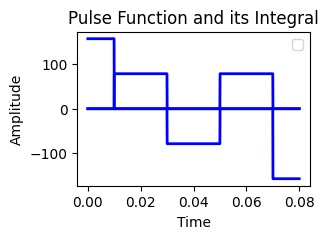

In [27]:
# 可视化函数和积分
t_plot = np.linspace(0, tmax, 1000)
pulse_valuesp = [Omega_p(t) for t in t_plot]
pulse_valuesp2 = [Omega_p2(t) for t in t_plot]
pulse_valuesc = [Omega_c(t) for t in t_plot]

plt.figure(figsize=(3, 2))
plt.plot(t_plot, pulse_valuesp, 'b-', linewidth=2)
plt.plot(t_plot, pulse_valuesp2, 'b-', linewidth=2)
plt.plot(t_plot, pulse_valuesc, 'b-', linewidth=2)


plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Pulse Function and its Integral')
plt.legend()
plt.grid(False)
plt.show()

In [28]:
#hc = np.array([[0, 0, 0],
#               [0, 0, omega_c/2],
#               [0, omega_c/2, 0]])

#hrr = np.array([[0, 0, 0],
#                [0, 0, 0],
#                [0, 0, 1]])

#hRR = np.array([[0, 0, 0, 0],
#                [0, 0, 0, 0],
#                [0, 0, 0, 0],
#                [0, 0, 0, 1]])

#hamiltonian
hc_op = gc * rc_dag + rc * gc_dag
ht_op = rt * et_dag + et * rt_dag
ht2_op = rt * gt_dag + gt * rt_dag
hrr_op = rc * rc_dag
hRR_op = rt * rt_dag

Hc_op = tensor(hc_op, Qobj(np.eye(3)), Qobj(np.eye(3)))
Ht_op1 = tensor(Qobj(np.eye(2)), ht_op, Qobj(np.eye(3))) + tensor(Qobj(np.eye(2)), Qobj(np.eye(3)), ht_op)
Ht_op2 = tensor(Qobj(np.eye(2)), ht2_op, Qobj(np.eye(3))) + tensor(Qobj(np.eye(2)), Qobj(np.eye(3)), ht2_op)

HRr = V_dd * (tensor(hrr_op, hRR_op, Qobj(np.eye(3))) + tensor(hrr_op, Qobj(np.eye(3)), hRR_op))
HRR = Vdw *  tensor(Qobj(np.eye(2)), hRR_op, hRR_op)


In [29]:
L_c = np.sqrt(gamma_c) * (gc * rc_dag)
L_R = np.sqrt(gamma_R) * (gt * rt_dag)

h_L1 = -1j/2 * (L_c.dag() * L_c)
h_L2 = -1j/2 * (L_R.dag() * L_R)

H_L = tensor(h_L1, Qobj(np.eye(3)), Qobj(np.eye(3))) + tensor(Qobj(np.eye(2)), h_L2, Qobj(np.eye(3))) + tensor(Qobj(np.eye(2)), Qobj(np.eye(3)), h_L2)

In [30]:
Hnhermitian = [H_L, HRr, HRR, [Hc_op,Omega_c], [Ht_op1, Omega_p], [Ht_op2, Omega_p2]]


In [31]:
c_ops = tensor(L_c, Qobj(np.eye(3)), Qobj(np.eye(3))) + tensor(Qobj(np.eye(2)), L_R, Qobj(np.eye(3))) + tensor(Qobj(np.eye(2)), Qobj(np.eye(3)), L_R)

In [32]:
c_ops

Quantum object: dims=[[2, 3, 3], [2, 3, 3]], shape=(18, 18), type='oper', dtype=CSR, isherm=False
Qobj data =
[[0.         0.         0.04449942 0.         0.         0.
  0.04449942 0.         0.         0.04271788 0.         0.
  0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.04449942 0.         0.         0.04271788 0.
  0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.04449942 0.         0.         0.04271788
  0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.04449942
  0.         0.         0.         0.         0.         0.
  0.04271788 0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0

In [33]:
psi00 = tensor(gc,gt,gt)
psi11 = tensor(gc,et,et)
psi_0 = tensor(Qobj(np.eye(2)),gt,gt)
psi_1 = tensor(Qobj(np.eye(2)),et,et)
psi_2 = tensor(Qobj(np.eye(2)),rt,rt)


In [34]:
mc = mcsolve(Hnhermitian, psi00, tlist, c_ops, [psi_0*psi_0.dag(), psi_1*psi_1.dag(), psi_2*psi_2.dag()],options={"map":"parallel","progress_bar":"enhanced"})

 Total run time:   4.32s*] Elapsed 4.30s / Remaining 00:00:00:00


In [35]:
mc1 = mcsolve(Hnhermitian, psi11, tlist, c_ops, [psi_0*psi_0.dag(), psi_1*psi_1.dag(), psi_2*psi_2.dag()],options={"map":"parallel","progress_bar":"enhanced"})

 Total run time:   4.44s*] Elapsed 4.42s / Remaining 00:00:00:00


In [36]:
print(mc.expect[0][999])
print(mc1.expect[1][999])


0.000246668072187342
0.0002478163803269103


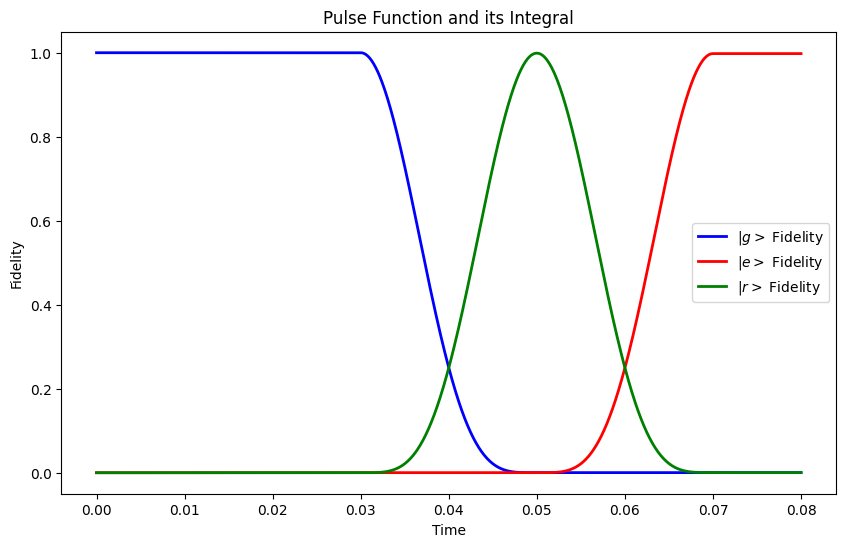

In [37]:
plt.figure(figsize=(10, 6))

plt.plot(tlist,mc.expect[0],'-b',lw=2,label='$|g>$ Fidelity')

plt.plot(tlist,mc.expect[1],'-r',lw=2,label='$|e>$ Fidelity')

plt.plot(tlist,mc.expect[2],'-g',lw=2,label='$|r>$ Fidelity')

plt.xlabel('Time')
plt.ylabel('Fidelity')
plt.title('Pulse Function and its Integral')
plt.legend()
plt.grid(False)
plt.show()
plt.show()

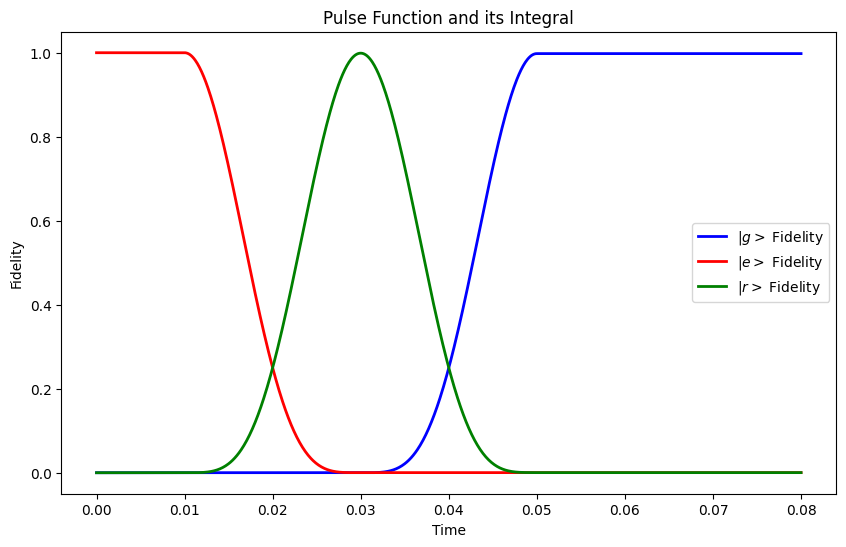

In [38]:
plt.figure(figsize=(10, 6))

plt.plot(tlist,mc1.expect[0],'-b',lw=2,label='$|g>$ Fidelity')

plt.plot(tlist,mc1.expect[1],'-r',lw=2,label='$|e>$ Fidelity')

plt.plot(tlist,mc1.expect[2],'-g',lw=2,label='$|r>$ Fidelity')

plt.xlabel('Time')
plt.ylabel('Fidelity')
plt.title('Pulse Function and its Integral')
plt.legend()
plt.grid(False)
plt.show()
plt.show()